In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_circles, make_blobs

In [ ]:
def get_moons(batch_size=256):
    X, _ = make_moons(n_samples=3000, noise=0.05)
    X = torch.FloatTensor(X)
    dataset = TensorDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def get_circles(batch_size=256):
    X,_=make_circles(n_samples=3000,noise=0.05)
    X=torch.FloatTensor(X)
    dataset=TensorDataset(X)
    return DataLoader(dataset, batch_size=batch_size,shuffle=True)

# def get_blobs(batch_size=256):
#     X,_=make_blobs(n_samples=3000)
#     X=torch.FloatTensor(X)
#     dataset=TensorDataset(X)
#     return DataLoader(dataset, batch_size=batch_size,shuffle=True)

In [ ]:
class LinearVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU() #adding non-linearities helps running without this and everything else same does not produce good results
        )

        self.mu_layer = nn.Linear(64, latent_dim)
        self.logvar_layer = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar, epoch):
    # Term 1: Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    beta=0.21 # The best generation that occured is here above this the 2 moons combine to form a wave lowering makes even more points in the part between the halves
    # Term 2: KL divergence from N(0, I)
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta*kl_loss, recon_loss, kl_loss

In [ ]:
def train_vae(model, train_loader, epochs=200, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = total_recon = total_kl = 0

        for batch in train_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            recon_x, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar, epoch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Loss: {total_loss:.2f} | Recon: {total_recon:.2f} | KL: {total_kl:.2f}")

In [ ]:
def plot_reconstructions(model, data, n=10):
    with torch.no_grad():
        recon, _, _ = model(data[:n])

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(data[:n, 0], data[:n, 1], c='blue', alpha=0.6)
    plt.title('Original Data')
    plt.subplot(1, 2, 2)
    plt.scatter(recon[:, 0], recon[:, 1], c='red', alpha=0.6)
    plt.title('Reconstructed Data')
    plt.show()

In [ ]:
def plot_latent_space(model, data):
    with torch.no_grad():
        mu, logvar = model.encode(data)

    plt.figure(figsize=(6, 6))
    plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5, s=10)
    plt.xlabel('Latent dim 1')
    plt.ylabel('Latent dim 2')
    plt.title('Latent Space')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
def plot_generated(model, n=1000):
    with torch.no_grad():
        z = torch.randn(n, 2)   # Sample from N(0, I)
        samples = model.decode(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5)
    plt.title('Generated Samples -- Pure Creation from Noise')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
vae=LinearVAE()
vae1=LinearVAE()

In [ ]:
data=get_moons()
train_vae(vae1,data,200,1e-2)

Epoch   0 | Loss: 2699.60 | Recon: 2374.18 | KL: 1549.61
Epoch  20 | Loss: 1351.25 | Recon: 538.89 | KL: 3868.39
Epoch  40 | Loss: 1328.40 | Recon: 515.98 | KL: 3868.66
Epoch  60 | Loss: 1334.63 | Recon: 498.65 | KL: 3980.86
Epoch  80 | Loss: 1342.69 | Recon: 522.81 | KL: 3904.21
Epoch 100 | Loss: 1327.46 | Recon: 527.02 | KL: 3811.60
Epoch 120 | Loss: 1329.97 | Recon: 528.45 | KL: 3816.77
Epoch 140 | Loss: 1333.96 | Recon: 526.39 | KL: 3845.61
Epoch 160 | Loss: 1329.98 | Recon: 520.63 | KL: 3854.03
Epoch 180 | Loss: 1338.75 | Recon: 517.28 | KL: 3911.76


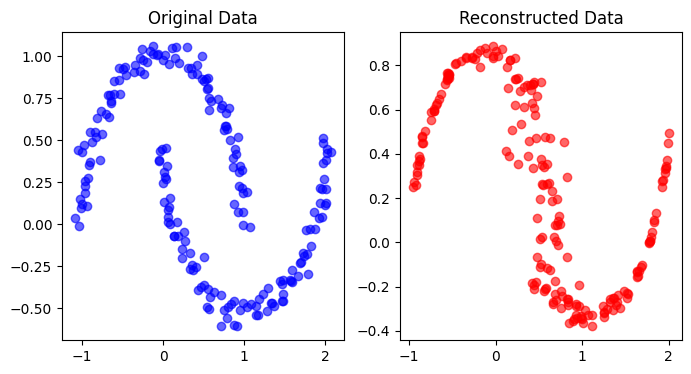

In [ ]:
X,_=make_moons(n_samples=200,noise=0.05)
X=torch.FloatTensor(X)
plot_reconstructions(vae1,X,n=500)

In [ ]:
data2=get_circles()
train_vae(vae,data2,200,1e-3)
Y,_=make_circles(n_samples=200,noise=0.05)
Y=torch.FloatTensor(Y)

Epoch   0 | Loss: 2533.21 | Recon: 2490.61 | KL: 202.84
Epoch  20 | Loss: 1388.54 | Recon: 550.87 | KL: 3988.91
Epoch  40 | Loss: 1368.57 | Recon: 525.88 | KL: 4012.84
Epoch  60 | Loss: 1367.98 | Recon: 506.20 | KL: 4103.72
Epoch  80 | Loss: 1377.55 | Recon: 506.66 | KL: 4147.10
Epoch 100 | Loss: 1366.06 | Recon: 471.23 | KL: 4261.08
Epoch 120 | Loss: 1339.76 | Recon: 474.24 | KL: 4121.54
Epoch 140 | Loss: 1347.20 | Recon: 488.57 | KL: 4088.70
Epoch 160 | Loss: 1363.24 | Recon: 510.71 | KL: 4059.66
Epoch 180 | Loss: 1350.13 | Recon: 480.12 | KL: 4142.91


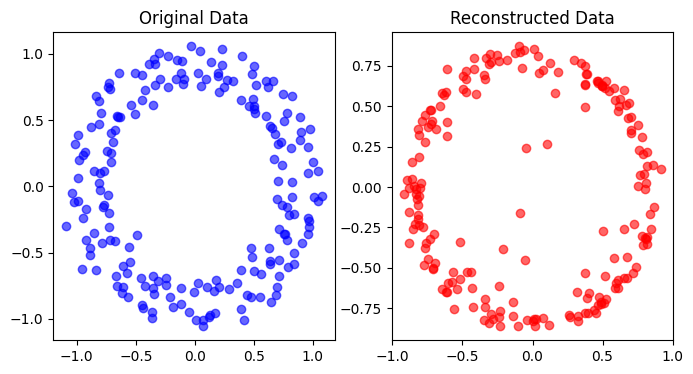

In [ ]:
plot_reconstructions(vae,Y,n=200)

In [ ]:
with torch.no_grad():
    mu,logvar=vae.encode(X)
print(mu.std(0))
print(logvar.mean())

tensor([0.5237, 1.0209])
tensor(-1.3963)


In [ ]:
with torch.no_grad():
    mu,logvar=vae.encode(Y)
print(mu.std(0))
print(logvar.mean())

tensor([0.8572, 0.8698])
tensor(-1.3651)


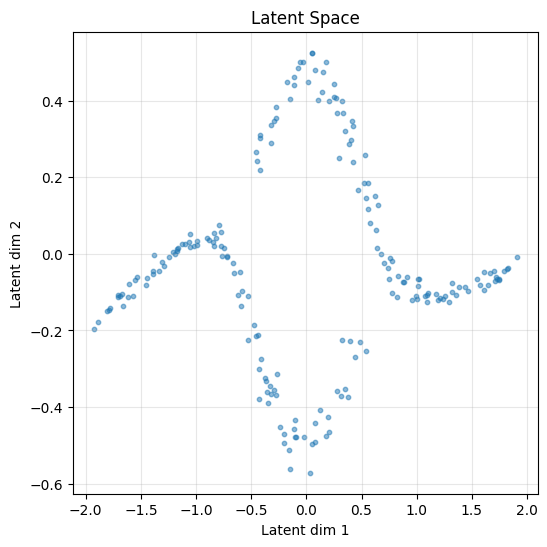

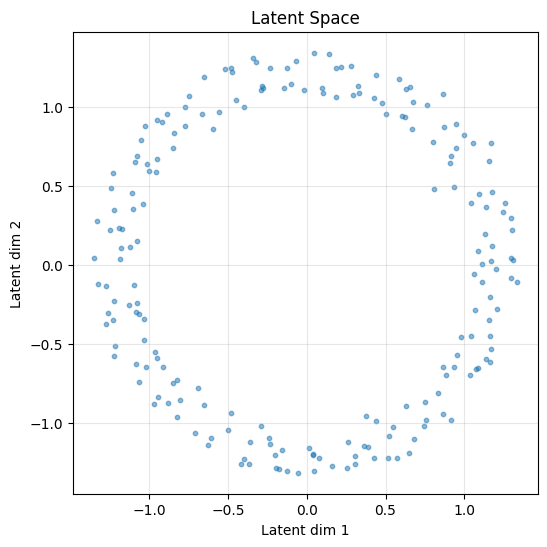

In [ ]:
plot_latent_space(vae1,X)
plot_latent_space(vae,Y)

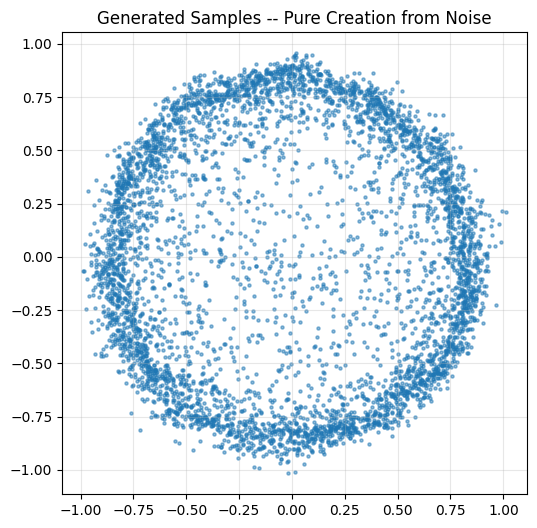

In [ ]:
plot_generated(vae,5000)

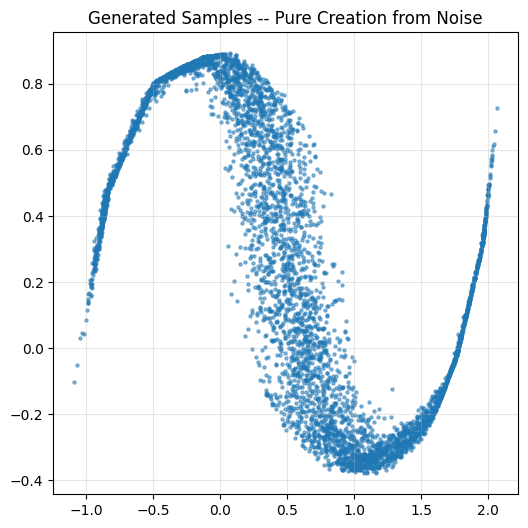

In [ ]:
plot_generated(vae1,5000)